# NER + BERTimbau + Clustering em Projetos de P&D

**Dataset:** `dadosTextosCientificos.tsv` (2.721 projetos, 2014) — encoding `latin-1`, não alterar.

**Pipeline:** NER (spaCy) → Embeddings (BERTimbau) → KMeans + Silhouette → PCA/t-SNE


## 1. Instalação e imports


In [1]:
# CÉLULA 1 - INSTALAÇÃO E IMPORTS
# ============================================================
# !pip install transformers torch scikit-learn spacy matplotlib seaborn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os, glob
import warnings
warnings.filterwarnings('ignore')

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
from spacy.training.iob_utils import offsets_to_biluo_tags

import torch
from transformers import AutoTokenizer, AutoModel

import random
import re

print("Imports OK")
print("GPU disponível:", torch.cuda.is_available())

# ============================================================

Imports OK
GPU disponível: False


## 2. Carregamento e limpeza do dataset


In [2]:
# CÉLULA 2 - CARREGAMENTO E LIMPEZA DO DATASET
# ============================================================

# ── Localiza o dataset automaticamente ──────────────────────────
KAGGLE_INPUT = "/kaggle/input"

def find_dataset_path():
    if os.path.isdir(KAGGLE_INPUT):
        all_files = []
        for root, _, files in os.walk(KAGGLE_INPUT):
            for f in files:
                if f.endswith((".tsv", ".csv")):
                    all_files.append(os.path.join(root, f))
        if all_files:
            return os.path.dirname(all_files[0]), all_files
    try:
        import kagglehub
        path = kagglehub.dataset_download("georgekurokijr/dl-2024")
        return path, None
    except Exception as e:
        raise RuntimeError(f"Não foi possível localizar o dataset: {e}")

def read_csv_latin1(file_path, sep=None):
    for enc in ["latin-1", "utf-8"]:
        try:
            df = pd.read_csv(file_path, encoding=enc, sep=sep, engine="python")
            print(f"  [OK] Codificação: {enc}")
            return df
        except Exception:
            continue
    raise ValueError(f"Não foi possível ler: {file_path}")

def load_dataset(base_path):
    supported = (".csv", ".tsv", ".json", ".jsonl", ".xlsx", ".parquet")
    files = [
        f for f in glob.glob(os.path.join(base_path, "**", "*"), recursive=True)
        if os.path.isfile(f) and f.lower().endswith(supported)
    ]
    if not files:
        raise FileNotFoundError("Nenhum arquivo tabular encontrado.")
    file_path = files[0]
    print(f"Arquivo: {file_path}")
    ext = file_path.lower()
    if ext.endswith(".tsv"):     return read_csv_latin1(file_path, sep="\t")
    if ext.endswith(".csv"):     return read_csv_latin1(file_path, sep=None)
    if ext.endswith(".jsonl"):   return pd.read_json(file_path, lines=True)
    if ext.endswith(".json"):    return pd.read_json(file_path)
    if ext.endswith(".xlsx"):    return pd.read_excel(file_path)
    if ext.endswith(".parquet"): return pd.read_parquet(file_path)
    raise ValueError(f"Formato não suportado: {file_path}")

# ── Carrega ──────────────────────────────────────────────────────
dataset_path, _ = find_dataset_path()
df = load_dataset(dataset_path)

print(f"\nShape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
try:
    display(df.head(3))
except NameError:
    print(df.head(3))

# ── Limpeza ──────────────────────────────────────────────────────
df = df.dropna(subset=['Título_Público', 'Descricao_pública']).reset_index(drop=True)

def limpar_texto(texto):
    texto = re.sub(r'\s+', ' ', texto)
    texto = re.sub(r'[^\w\sáéíóúâêîôûãõàèìòùäëïöüçñ.,;:!?()-]', ' ', texto)
    return texto.strip()

df['texto'] = (df['Título_Público'].str.strip() + '. ' + df['Descricao_pública'].str.strip()).apply(limpar_texto)

print(f"\nShape após limpeza: {df.shape}")
print(f"Nulos restantes:\n{df.isnull().sum()}")

Arquivo: /kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv
  [OK] Codificação: latin-1

Shape: (2725, 2)
Colunas: ['Título_Público', 'Descricao_pública']


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...



Shape após limpeza: (2721, 3)
Nulos restantes:
Título_Público       0
Descricao_pública    0
texto                0
dtype: int64


## 3. TF-IDF exploratório


=== TOP 40 TERMOS MAIS RELEVANTES (excluindo genéricos) ===
        termo    score
           ao 0.044303
   utilizando 0.028811
      energia 0.026341
     ambiente 0.023378
  equipamento 0.021345
     hardware 0.019673
  tecnologica 0.019549
         rota 0.019251
          iot 0.018931
 propriedades 0.018688
        capaz 0.018683
  comunicacao 0.018629
     realizar 0.018401
gerenciamento 0.018222
      geracao 0.018121
      reducao 0.017654
     material 0.017517
    automacao 0.017383
     conceito 0.017350
   manufatura 0.017241
      avaliar 0.017237
        saude 0.016686
    validacao 0.016585
      digital 0.016463
   fabricacao 0.016320
     veiculos 0.016147
    seguranca 0.016029
   integracao 0.015895
       escala 0.015676
     deteccao 0.015569
          aos 0.015507
 inteligentes 0.015502
     obtencao 0.015484
  resistencia 0.015209
      aumento 0.015044
  metodologia 0.014980
    embarcado 0.014932
      consumo 0.014873
computacional 0.014722
        tempo 0.0145

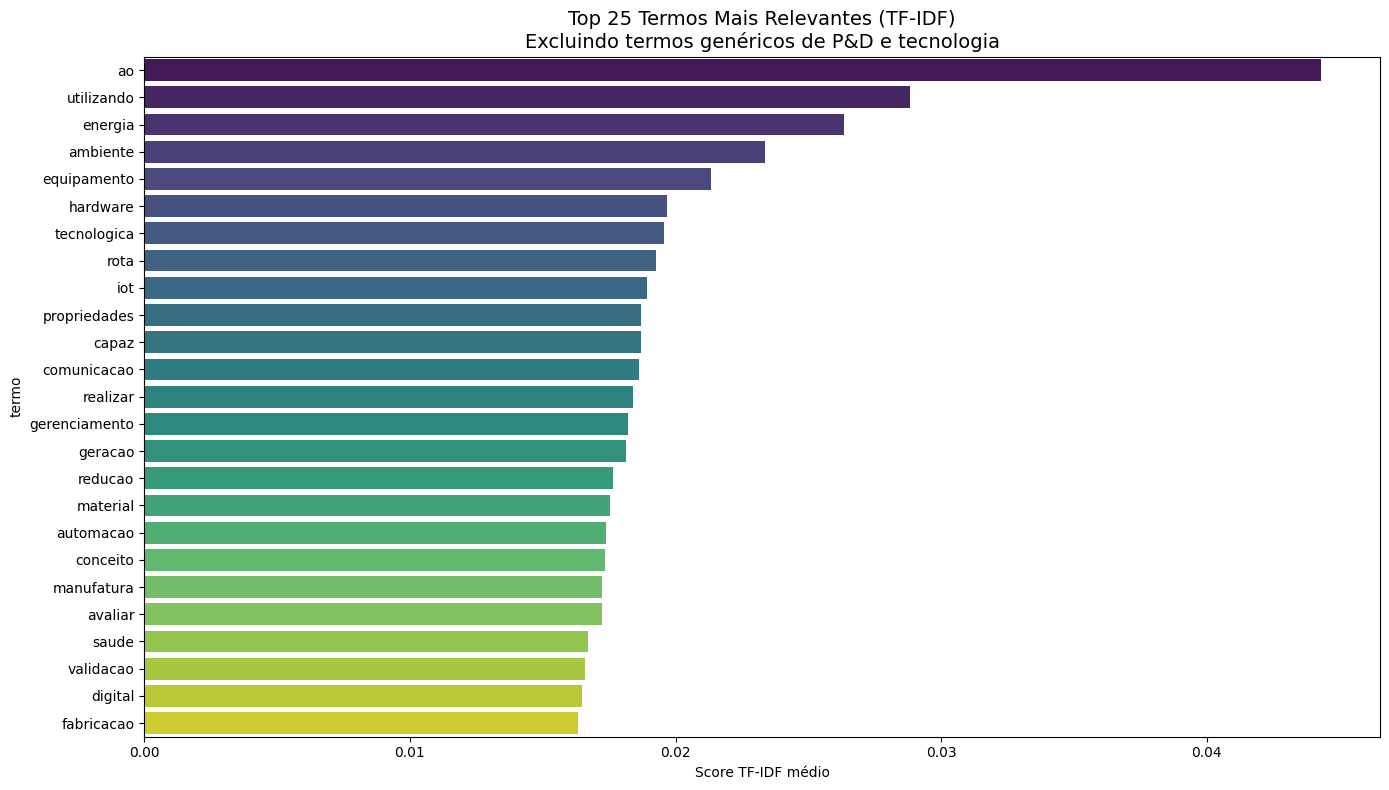

Gráfico salvo: tfidf_exploratório.png


In [3]:
# CÉLULA 3 - TF-IDF EXPLORATÓRIO
# Objetivo: Ver termos mais relevantes e identificar ruídos
# ============================================================

# Stopwords: termos genéricos de P&D + português básico
STOPWORDS = [
    # artigos, preposições, pronomes
    'a','o','as','os','um','uma','uns','umas',
    'de','do','da','dos','das','em','no','na','nos','nas',
    'por','pelo','pela','pelos','pelas','para','pra','com',
    'sem','sob','sobre','entre','até','após','antes','desde',
    'e','ou','mas','porém','contudo','todavia','porque','pois',
    'que','se','quando','enquanto','como','conforme','embora','caso',
    'eu','tu','ele','ela','nós','vós','eles','elas',
    'me','te','se','nos','vos','meu','minha','seu','sua',
    'este','esta','esse','essa','aquele','aquela','isto','isso','aquilo',
    # verbos comuns
    'ser','estar','ter','haver','fazer','ir','vir',
    'foi','foram','era','eram','são','é','está','estão',
    'tem','têm','tinha','tinham','há','houve','havia',
    'faz','fez','vai','vão','pode','podem','deve','devem',
    'busca','visa','visando','permite','sendo','tendo',
    # advérbios
    'não','sim','também','ainda','já','sempre','nunca',
    'muito','pouco','mais','menos','bem','mal',
    'aqui','ali','lá','onde','agora','depois','antes',
    # termos MUITO genéricos de P&D (ruídos)
    'projeto','projetos','desenvolvimento','desenvolver','desenvolvido',
    'solução','soluções','sistema','sistemas','processo','processos',
    'produto','produtos','tecnologia','tecnologias','uso','utilização',
    'utilizar','utilizado','aplicação','aplicações','método','métodos',
    'modelo','modelos','análise','avaliação','estudo','pesquisa',
    'dados','informações','empresa','empresas','área','áreas',
    'setor','setores','objetivo','objetivos','resultado','resultados',
    'forma','meio','parte','tipo','nível','inovação','inovar',
    'técnico','técnica','brasil','brasileiro','brasileira',
    'novos','novas','novo','nova','alta','alto','baixo','baixa',
    'grande','maior','menor','melhor','diferente','diferentes',
    'presente','proposta','base','deste','desta','pelo','pela',
    'assim','além','através','durante','após','partir','modo',
    'mercado','qualidade','eficiência','otimização','desempenho',
    'plataforma','software','dispositivo','dispositivos','protótipo',
    'testes','componentes','equipamentos','materiais','técnicas',
    'gestão','monitoramento','controle','produção','indústria',
    'inteligência','artificial','inteligente','processamento',
    'tratamento','resíduos','serão','sera','alem','atraves',
]

# Remove acentos das stopwords para casar com strip_accents='unicode' do vetorizador
import unicodedata

def remove_acentos(s):
    return unicodedata.normalize('NFKD', s).encode('ASCII', 'ignore').decode('utf-8')

STOPWORDS = [remove_acentos(w) for w in STOPWORDS]

vectorizer_explorat = TfidfVectorizer(
    max_features=100,
    stop_words=STOPWORDS,
    ngram_range=(1, 2),
    min_df=5,
    strip_accents='unicode',
    lowercase=True
)

tfidf_matrix = vectorizer_explorat.fit_transform(df['texto'])
termos = vectorizer_explorat.get_feature_names_out()
scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

df_termos = pd.DataFrame({'termo': termos, 'score': scores})
df_termos = df_termos.sort_values('score', ascending=False).head(40)

print("=== TOP 40 TERMOS MAIS RELEVANTES (excluindo genéricos) ===")
print(df_termos.to_string(index=False))

# Visualização
plt.figure(figsize=(14, 8))
sns.barplot(data=df_termos.head(25), x='score', y='termo', palette='viridis')
plt.title('Top 25 Termos Mais Relevantes (TF-IDF)\nExcluindo termos genéricos de P&D e tecnologia', fontsize=14)
plt.xlabel('Score TF-IDF médio')
plt.tight_layout()
plt.savefig('tfidf_exploratório.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: tfidf_exploratório.png")

# ============================================================

## 4. Dados de treino do NER


In [4]:
# CÉLULA 4 - CRIAÇÃO DO TRAINING DATA PARA NER
# Entidades NÃO-TECNOLÓGICAS do domínio de P&D brasileiro
#
# Categorias:
#   AREA_APLICACAO  → Setor de aplicação (saúde, energia, alimentos...)
#   BENEFICIARIO    → Quem se beneficia (comunidades, agricultores...)
#   RECURSO_NATURAL → Recursos naturais/biológicos usados
#   ODS             → Objetivos de Desenvolvimento Sustentável
#   BIOMA           → Biomas brasileiros mencionados
# ============================================================

TRAINING_DATA = [
    # ---- ÁREA DE APLICAÇÃO ----
    ("O projeto visa desenvolver soluções para a área de saúde pública.",
     {"entities": [(51, 64, "AREA_APLICACAO")]}),
    ("Esse produto será aplicado no setor alimentício nacional.",
     {"entities": [(30, 47, "AREA_APLICACAO")]}),
    ("A tecnologia tem aplicação direta na área agropecuária.",
     {"entities": [(42, 54, "AREA_APLICACAO")]}),
    ("O sistema contribui para o setor energético brasileiro.",
     {"entities": [(27, 43, "AREA_APLICACAO")]}),
    ("Desenvolvemos uma solução voltada para construção civil.",
     {"entities": [(39, 55, "AREA_APLICACAO")]}),
    ("Esta pesquisa impacta o setor de educação básica.",
     {"entities": [(33, 48, "AREA_APLICACAO")]}),
    ("O equipamento é destinado ao setor de mineração.",
     {"entities": [(38, 47, "AREA_APLICACAO")]}),
    ("A solução atende demandas do agronegócio nacional.",
     {"entities": [(29, 40, "AREA_APLICACAO")]}),
    ("Produto voltado para a indústria alimentícia.",
     {"entities": [(23, 44, "AREA_APLICACAO")]}),
    ("O projeto tem aplicação na área ambiental e sustentável.",
     {"entities": [(32, 41, "AREA_APLICACAO")]}),
    ("Solução inovadora para o setor têxtil.",
     {"entities": [(25, 37, "AREA_APLICACAO")]}),
    ("Sistema criado para o setor de logística.",
     {"entities": [(22, 40, "AREA_APLICACAO")]}),
    ("O produto tem impacto direto na saúde animal.",
     {"entities": [(32, 44, "AREA_APLICACAO")]}),
    ("Tecnologia voltada para a geração de energia renovável.",
     {"entities": [(37, 54, "AREA_APLICACAO")]}),
    ("Produto desenvolvido para a área de nutrição humana.",
     {"entities": [(36, 51, "AREA_APLICACAO")]}),

    # ---- BENEFICIÁRIO ----
    ("O objetivo é beneficiar comunidades isoladas do interior.",
     {"entities": [(24, 44, "BENEFICIARIO")]}),
    ("A solução foi criada para pequenos agricultores da região.",
     {"entities": [(26, 47, "BENEFICIARIO")]}),
    ("O projeto beneficia populações ribeirinhas da Amazônia.",
     {"entities": [(20, 42, "BENEFICIARIO")]}),
    ("Desenvolvido para atender as necessidades dos produtores rurais.",
     {"entities": [(46, 63, "BENEFICIARIO")]}),
    ("O produto é destinado a pacientes oncológicos.",
     {"entities": [(24, 45, "BENEFICIARIO")]}),
    ("A plataforma auxilia micro e pequenas empresas.",
     {"entities": [(21, 46, "BENEFICIARIO")]}),
    ("Beneficia diretamente a indústria de alimentos.",
     {"entities": [(24, 46, "BENEFICIARIO")]}),
    ("Voltado para trabalhadores rurais do Nordeste.",
     {"entities": [(13, 33, "BENEFICIARIO")]}),
    ("O sistema atende escolas públicas de regiões carentes.",
     {"entities": [(17, 33, "BENEFICIARIO")]}),
    ("Produto pensado para idosos com mobilidade reduzida.",
     {"entities": [(21, 27, "BENEFICIARIO")]}),

    # ---- RECURSO NATURAL ----
    ("O produto é baseado na extração de açaí da floresta amazônica.",
     {"entities": [(35, 39, "RECURSO_NATURAL")]}),
    ("Utiliza biomassa de cana-de-açúcar como insumo principal.",
     {"entities": [(8, 16, "RECURSO_NATURAL"), (20, 34, "RECURSO_NATURAL")]}),
    ("O processo usa castanha-do-brasil como matéria-prima.",
     {"entities": [(15, 33, "RECURSO_NATURAL")]}),
    ("Desenvolvido a partir de óleos vegetais nativos do Cerrado.",
     {"entities": [(25, 39, "RECURSO_NATURAL")]}),
    ("Utiliza fungos entomopatogênicos no processo.",
     {"entities": [(8, 32, "RECURSO_NATURAL")]}),
    ("A madeira de reflorestamento é a principal matéria-prima.",
     {"entities": [(2, 28, "RECURSO_NATURAL")]}),
    ("Baseado em extratos de plantas medicinais do Cerrado.",
     {"entities": [(11, 41, "RECURSO_NATURAL")]}),
    ("Usa resíduos de soja para produzir biopolímeros.",
     {"entities": [(4, 20, "RECURSO_NATURAL")]}),
    ("O insumo principal é o latex natural da seringueira.",
     {"entities": [(23, 36, "RECURSO_NATURAL"), (40, 51, "RECURSO_NATURAL")]}),
    ("A proposta envolve uso de algas marinhas como matéria-prima.",
     {"entities": [(26, 40, "RECURSO_NATURAL")]}),

    # ---- ODS ----
    ("Contribui para o Objetivo 3 da ONU, que trata de saúde e bem-estar.",
     {"entities": [(17, 34, "ODS")]}),
    ("Alinhado ao ODS 7 - energia limpa e acessível.",
     {"entities": [(12, 17, "ODS"), (20, 45, "ODS")]}),
    ("O projeto apoia os Objetivos de Desenvolvimento Sustentável da ONU.",
     {"entities": [(19, 59, "ODS")]}),
    ("Alinhado ao Objetivo 12 de produção e consumo responsáveis.",
     {"entities": [(12, 23, "ODS")]}),
    ("Contribui para o ODS 2 - fome zero e agricultura sustentável.",
     {"entities": [(17, 22, "ODS")]}),
    ("Apoia o cumprimento do ODS 13 sobre ação contra a mudança do clima.",
     {"entities": [(23, 29, "ODS")]}),
    ("Relacionado ao ODS 6, que visa água limpa e saneamento.",
     {"entities": [(15, 20, "ODS")]}),
    ("Alinhado ao Objetivo de Desenvolvimento Sustentável número 11.",
     {"entities": [(12, 51, "ODS")]}),

    # ---- BIOMA ----
    ("O projeto explora a biodiversidade da Amazônia brasileira.",
     {"entities": [(38, 46, "BIOMA")]}),
    ("Utiliza espécies nativas do Cerrado para produção.",
     {"entities": [(28, 35, "BIOMA")]}),
    ("A pesquisa é baseada em plantas da Mata Atlântica.",
     {"entities": [(35, 49, "BIOMA")]}),
    ("Os recursos provêm da Caatinga, bioma semiárido.",
     {"entities": [(22, 30, "BIOMA")]}),
    ("Desenvolvido com espécies do Pantanal sul-mato-grossense.",
     {"entities": [(29, 37, "BIOMA")]}),
    ("Baseado na flora da região do Pampa gaúcho.",
     {"entities": [(30, 35, "BIOMA")]}),
    ("Explora recursos pesqueiros do bioma costeiro marinho.",
     {"entities": [(31, 45, "BIOMA")]}),
    ("Desenvolvido com insumos da floresta amazônica.",
     {"entities": [(28, 46, "BIOMA")]}),
]

print(f"Total de exemplos de treinamento: {len(TRAINING_DATA)}")
print("Entidades definidas: AREA_APLICACAO, BENEFICIARIO, RECURSO_NATURAL, ODS, BIOMA")

# Validação automática dos offsets
print("\n=== VALIDAÇÃO DOS OFFSETS ===")
erros = 0
for text, ann in TRAINING_DATA:
    for start, end, label in ann["entities"]:
        span = text[start:end]
        if not span.strip() or span.startswith(" ") or span.endswith(" "):
            print(f"  ⚠️  [{label}] offset ({start},{end}) → \'{span}\' — espaço nas bordas")
            erros += 1
        else:
            print(f"  ✅ [{label}] \'{span}\'")
print(f"\nErros encontrados: {erros}")


Total de exemplos de treinamento: 51
Entidades definidas: AREA_APLICACAO, BENEFICIARIO, RECURSO_NATURAL, ODS, BIOMA

=== VALIDAÇÃO DOS OFFSETS ===
  ✅ [AREA_APLICACAO] 'saúde pública'
  ✅ [AREA_APLICACAO] 'setor alimentício'
  ✅ [AREA_APLICACAO] 'agropecuária'
  ✅ [AREA_APLICACAO] 'setor energético'
  ✅ [AREA_APLICACAO] 'construção civil'
  ✅ [AREA_APLICACAO] 'educação básica'
  ✅ [AREA_APLICACAO] 'mineração'
  ✅ [AREA_APLICACAO] 'agronegócio'
  ✅ [AREA_APLICACAO] 'indústria alimentícia'
  ✅ [AREA_APLICACAO] 'ambiental'
  ✅ [AREA_APLICACAO] 'setor têxtil'
  ✅ [AREA_APLICACAO] 'setor de logística'
  ✅ [AREA_APLICACAO] 'saúde animal'
  ✅ [AREA_APLICACAO] 'energia renovável'
  ✅ [AREA_APLICACAO] 'nutrição humana'
  ✅ [BENEFICIARIO] 'comunidades isoladas'
  ✅ [BENEFICIARIO] 'pequenos agricultores'
  ✅ [BENEFICIARIO] 'populações ribeirinhas'
  ✅ [BENEFICIARIO] 'produtores rurais'
  ✅ [BENEFICIARIO] 'pacientes oncológicos'
  ✅ [BENEFICIARIO] 'micro e pequenas empresas'
  ✅ [BENEFICIARIO] 'in

## 5. Treinamento do NER


In [5]:
# CÉLULA 5 - TREINAMENTO DO NER
# ============================================================

nlp = spacy.blank("pt")
ner = nlp.add_pipe("ner")

for text, annotations in TRAINING_DATA:
    for start, end, label in annotations.get("entities", []):
        ner.add_label(label)

print("Labels registrados:", ner.labels)

def is_valid_example(nlp, text, annotations):
    doc = nlp.make_doc(text)
    entities = annotations.get("entities", [])
    try:
        tags = offsets_to_biluo_tags(doc, entities)
    except Exception as e:
        return False
    if "-" in tags:
        return False
    return True

def make_examples(nlp, training_data):
    examples = []
    for text, annotations in training_data:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)
        examples.append(example)
    return examples

TRAINING_DATA_VALID = [
    (text, ann)
    for text, ann in TRAINING_DATA
    if is_valid_example(nlp, text, ann)
]

print(f"Exemplos válidos: {len(TRAINING_DATA_VALID)}/{len(TRAINING_DATA)}")

initial_examples = make_examples(nlp, TRAINING_DATA_VALID)
optimizer = nlp.initialize(lambda: initial_examples)

N_ITER = 80
random.seed(42)

print("Iniciando treinamento NER...")
for iteration in range(N_ITER):
    random.shuffle(TRAINING_DATA_VALID)
    losses = {}
    batches = minibatch(TRAINING_DATA_VALID, size=compounding(4.0, 16.0, 1.001))
    for batch in batches:
        examples = make_examples(nlp, batch)
        nlp.update(examples, sgd=optimizer, drop=0.3, losses=losses)
    if (iteration + 1) % 20 == 0:
        print(f"  Iteração {iteration+1}/{N_ITER} | Loss NER: {losses.get('ner', 0):.4f}")
    if losses.get("ner", 1) < 0.005:
        print(f"  Early stopping na iteração {iteration+1}")
        break

nlp.to_disk("modelo_ner_pdri")
print("Modelo salvo em: modelo_ner_pdri/")

# ============================================================

Labels registrados: ('AREA_APLICACAO', 'BENEFICIARIO', 'BIOMA', 'ODS', 'RECURSO_NATURAL')
Exemplos válidos: 51/51
Iniciando treinamento NER...
  Iteração 20/80 | Loss NER: 28.9433
  Iteração 40/80 | Loss NER: 1.9773
  Early stopping na iteração 54
Modelo salvo em: modelo_ner_pdri/


## 6. Aplicação do NER no dataset


In [6]:
# CÉLULA 6 - APLICAR NER NOS TEXTOS DO DATASET
# ============================================================

import os
if not os.path.isdir("modelo_ner_pdri"):
    raise RuntimeError("Modelo NER não encontrado — rode a CÉLULA 5 (treinamento) antes desta célula.")
nlp_ner = spacy.load("modelo_ner_pdri")

print("Testando NER em exemplos reais:")
for i in [0, 5, 50, 100, 200]:
    if i < len(df):
        doc = nlp_ner(df['texto'][i])
        ents = [(ent.text, ent.label_) for ent in doc.ents]
        if ents:
            print(f"\n[{i}] {df['Título_Público'][i]}")
            print(f"  Entidades: {ents}")

# Extrair entidades de todos os textos (em lote, mais rápido que apply linha a linha)
def extrair_entidades_lote(textos, batch_size=64):
    resultados = []
    for doc in nlp_ner.pipe((t[:500] for t in textos), batch_size=batch_size):
        resultados.append([(ent.text, ent.label_) for ent in doc.ents])
    return resultados

df['entidades_ner'] = extrair_entidades_lote(df['texto'].tolist())

# Criar colunas por tipo de entidade
for label in ['AREA_APLICACAO', 'BENEFICIARIO', 'RECURSO_NATURAL', 'ODS', 'BIOMA']:
    df[f'ner_{label.lower()}'] = df['entidades_ner'].apply(
        lambda ents: ', '.join([e[0] for e in ents if e[1] == label]) or None
    )

print(f"\nDistribuição de entidades encontradas:")
for label in ['AREA_APLICACAO', 'BENEFICIARIO', 'RECURSO_NATURAL', 'ODS', 'BIOMA']:
    col = f'ner_{label.lower()}'
    n = df[col].notna().sum()
    print(f"  {label:20s}: {n:4d} projetos ({n/len(df)*100:.1f}%)")

# ============================================================

Testando NER em exemplos reais:

[0] Açúcar de frutas e aplicação em bolos como substituto da sacarose
  Entidades: [('bolos', 'RECURSO_NATURAL'), ('recursos de base', 'RECURSO_NATURAL'), ('Brasil', 'BIOMA'), ('maneira, contribui', 'RECURSO_NATURAL'), ('Objetivos de Desenvolvimento Sustentável', 'ODS'), ('ODS)', 'ODS'), ('Objetivo 12', 'ODS'), ('indústrias de alimentos', 'RECURSO_NATURAL')]

[5] Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco
  Entidades: [('Mato Grosso', 'BIOMA'), ('inclusão de produtos', 'RECURSO_NATURAL'), ('nossa', 'RECURSO_NATURAL'), ('estudo sobre', 'BIOMA'), ('possíveis', 'BIOMA'), ('bioma Cerrado', 'BIOMA'), ('Pantanal', 'BIOMA'), ('mercado vegano', 'AREA_APLICACAO'), ('consumidores que', 'BENEFICIARIO')]

[50] Ar-Tools
  Entidades: [('software', 'BIOMA'), ('manutenção de equipamentos', 'BENEFICIARIO')]

[100] Embedded-SOC
  Entidades: [('coerentes ópticas', 'BENEFICIARIO')]

[200] Plataforma Unificada de Serviços Corpor

## 7. Embeddings com BERTimbau


In [7]:
# CÉLULA 7 - EMBEDDINGS COM BERTIMBAU
# ============================================================

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 128
BATCH_SIZE = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

def generate_embeddings(texts, batch_size=BATCH_SIZE):
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = bert_model(**encoded)
            batch_emb = mean_pooling(outputs.last_hidden_state, encoded['attention_mask'])
        all_embeddings.append(batch_emb.cpu().numpy())
        if (start // batch_size + 1) % 10 == 0:
            print(f"  Batch {start // batch_size + 1}/{len(texts) // batch_size + 1}")
    return np.vstack(all_embeddings)

print("Gerando embeddings com BERTimbau...")
# Usar título + primeiros 200 chars da descrição para economizar memória
textos_resumidos = (df['Título_Público'] + '. ' + df['Descricao_pública'].str[:200]).tolist()
embeddings = generate_embeddings(textos_resumidos)
print(f"Shape dos embeddings: {embeddings.shape}")

# ============================================================

Dispositivo: cpu


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Gerando embeddings com BERTimbau...
  Batch 10/171
  Batch 20/171
  Batch 30/171
  Batch 40/171
  Batch 50/171
  Batch 60/171
  Batch 70/171
  Batch 80/171
  Batch 90/171
  Batch 100/171
  Batch 110/171
  Batch 120/171
  Batch 130/171
  Batch 140/171
  Batch 150/171
  Batch 160/171
  Batch 170/171
Shape dos embeddings: (2721, 768)


## 8. Clusterização (KMeans + Silhouette)


Calculando Silhouette Score para diferentes k...
  k= 4 | Silhouette: 0.0534
  k= 5 | Silhouette: 0.0473
  k= 6 | Silhouette: 0.0479
  k= 7 | Silhouette: 0.0476
  k= 8 | Silhouette: 0.0355
  k= 9 | Silhouette: 0.0296
  k=10 | Silhouette: 0.0268
  k=11 | Silhouette: 0.0284
  k=12 | Silhouette: 0.0307

Melhor k: 4 (Silhouette: 0.0534)


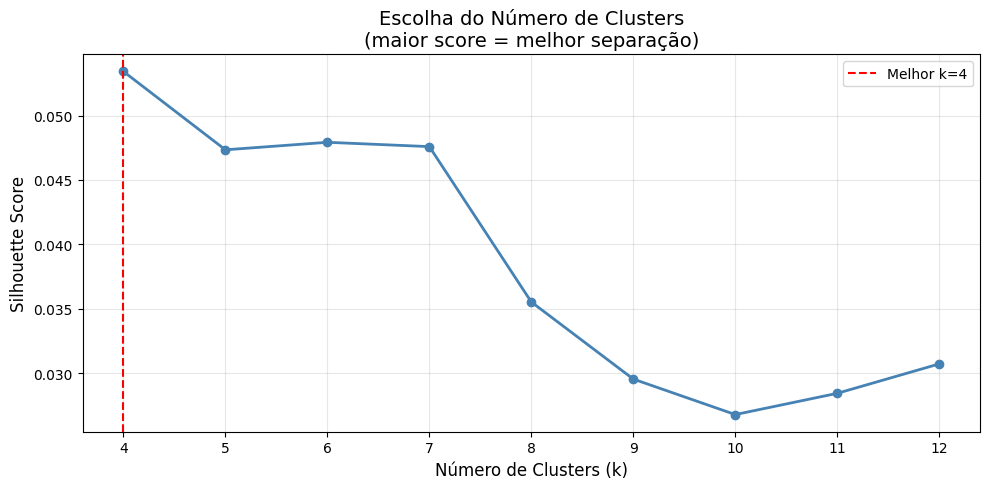


Distribuição por cluster:
cluster
0     221
1    1037
2     516
3     947
Name: count, dtype: int64


In [8]:
# CÉLULA 8 - CLUSTERIZAÇÃO COM KMEANS
# Escolha automática do k via Silhouette Score
# ============================================================

RANDOM_STATE = 42
MIN_K = 4
MAX_K = 12

print("Calculando Silhouette Score para diferentes k...")
silhouette_results = []

for k in range(MIN_K, MAX_K + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    silhouette_results.append({'k': k, 'silhouette': score})
    print(f"  k={k:2d} | Silhouette: {score:.4f}")

sil_df = pd.DataFrame(silhouette_results)
best_k = int(sil_df.loc[sil_df['silhouette'].idxmax(), 'k'])
print(f"\nMelhor k: {best_k} (Silhouette: {sil_df['silhouette'].max():.4f})")

# Plot Silhouette
plt.figure(figsize=(10, 5))
plt.plot(sil_df['k'], sil_df['silhouette'], marker='o', linewidth=2, color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Melhor k={best_k}')
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Escolha do Número de Clusters\n(maior score = melhor separação)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# KMeans final
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init='auto')
df['cluster'] = kmeans_final.fit_predict(embeddings)

print(f"\nDistribuição por cluster:")
print(df['cluster'].value_counts().sort_index())

# ============================================================

## 9. TF-IDF por cluster


In [9]:
# CÉLULA 9 - TF-IDF POR CLUSTER
# Identificar termos representativos de cada grupo
# ============================================================

vectorizer_cluster = TfidfVectorizer(
    max_features=5000,
    stop_words=STOPWORDS,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents='unicode',
    lowercase=True
)

tfidf_matrix_cluster = vectorizer_cluster.fit_transform(df['texto'])
termos_vocab = np.array(vectorizer_cluster.get_feature_names_out())

cluster_summary = []

for cluster_id in sorted(df['cluster'].unique()):
    idx = df.index[df['cluster'] == cluster_id].tolist()
    media_tfidf = np.asarray(tfidf_matrix_cluster[idx].mean(axis=0)).ravel()
    top_idx = media_tfidf.argsort()[::-1][:15]
    top_termos = termos_vocab[top_idx]
    
    # Exemplos de títulos desse cluster
    exemplos = df[df['cluster'] == cluster_id]['Título_Público'].head(5).tolist()
    
    cluster_summary.append({
        'cluster': cluster_id,
        'quantidade': len(idx),
        'termos_representativos': ', '.join(top_termos),
        'exemplos_titulos': ' | '.join(exemplos)
    })

cluster_df = pd.DataFrame(cluster_summary)
print("\n=== RESUMO DOS CLUSTERS ===\n")
for _, row in cluster_df.iterrows():
    print(f"CLUSTER {row['cluster']} ({row['quantidade']} projetos)")
    print(f"  Termos: {row['termos_representativos']}")
    print(f"  Exemplos: {row['exemplos_titulos'][:200]}")
    print()

# ============================================================


=== RESUMO DOS CLUSTERS ===

CLUSTER 0 (221 projetos)
  Termos: energia, es, ncia, ao, material, material composito, capacidade, composito, utilizando, eletronica, aguardando autorizacao, natural, aguardando, autorizacao, veiculos
  Exemplos: HUAWEI SOLAR TRACKING CONTROL (AI BASED) | ACELERA VTEX | DESENVOLVIMENTO DE HARDWARE DE AQUISIÇÃO PARA AUTOMAÇÃO NO REGISTRO E ENVIO DE INFORMAÇÕES DE ARRAÇOAMENTOS | PROJETO INTELIGÊNCIA NAS EXECUÇÕ

CLUSTER 1 (1037 projetos)
  Termos: energia, ao, ambiente, comunicacao, realizar, maquina, algoritmos, computacional, gerenciamento, veiculos, utilizando, iot, saude, capaz, ia
  Exemplos: AgriGear - Superacabamento de engrenagens para aumento da capacidade de carga de engrenagens agrícolas | Caixa de Transmissão IoT para monitoramento de vida - Gearbox Connect | AGROSYSTEM | Siemens-En

CLUSTER 2 (516 projetos)
  Termos: embarcado, iot, gerenciamento, smart, suporte, modulo, comunicacao, automacao, digital, nuvem, hardware, integracao, equipamento

## 10. Interpretação dos clusters (preencher manualmente)


In [10]:
# CÉLULA 10 - INTERPRETAÇÃO DOS CLUSTERS (PREENCHER MANUALMENTE)
# Com base nos termos e exemplos acima, nomear cada cluster
# ============================================================

# ATENÇÃO: Preencha os nomes abaixo após analisar a célula 9!
# Exemplos de nomes possíveis:
interpretacoes = {
    0: "Alimentos & Bioeconomia",
    1: "Energia & Sustentabilidade",
    2: "Saúde & Dispositivos Médicos",
    3: "Construção Civil & Materiais",
    4: "Agropecuária & Meio Ambiente",
    5: "Gestão Industrial & Processos",
    6: "Smart Cities & Mobilidade",
    7: "Mineração & Recursos Naturais",
}
# Adicionar mais conforme o best_k

df['cluster_nome'] = df['cluster'].map(interpretacoes).fillna('Outros')

print("=== CLUSTERS COM NOMES INTERPRETADOS ===")
print(df.groupby(['cluster', 'cluster_nome']).size().reset_index(name='projetos'))

# ============================================================

=== CLUSTERS COM NOMES INTERPRETADOS ===
   cluster                  cluster_nome  projetos
0        0       Alimentos & Bioeconomia       221
1        1    Energia & Sustentabilidade      1037
2        2  Saúde & Dispositivos Médicos       516
3        3  Construção Civil & Materiais       947


## 11. PCA (visão global)


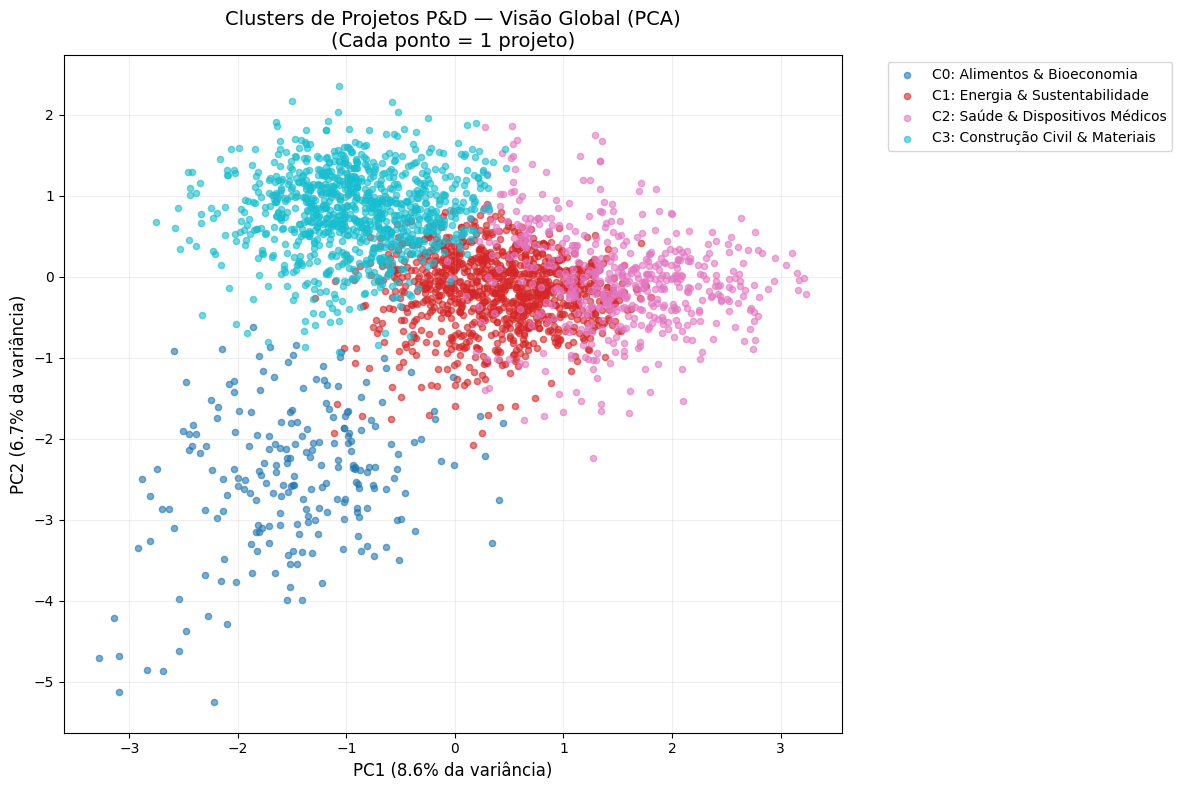

Salvo: clusters_pca.png


In [11]:
# CÉLULA 11 - VISUALIZAÇÃO PCA (visão global)
# PCA mostra separação GLOBAL entre clusters
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pontos_pca = pca.fit_transform(embeddings)

plot_df_pca = pd.DataFrame({
    'x': pontos_pca[:, 0],
    'y': pontos_pca[:, 1],
    'cluster': df['cluster'].astype(str),
    'nome': df['cluster_nome']
})

cores = cm.tab10(np.linspace(0, 1, best_k))

plt.figure(figsize=(12, 8))
for i, cid in enumerate(sorted(df['cluster'].unique())):
    subset = plot_df_pca[plot_df_pca['cluster'] == str(cid)]
    nome = interpretacoes.get(cid, f'Cluster {cid}')
    plt.scatter(subset['x'], subset['y'], 
                label=f"C{cid}: {nome}", 
                alpha=0.6, s=20, color=cores[i])

variancia = pca.explained_variance_ratio_
plt.xlabel(f'PC1 ({variancia[0]*100:.1f}% da variância)', fontsize=12)
plt.ylabel(f'PC2 ({variancia[1]*100:.1f}% da variância)', fontsize=12)
plt.title('Clusters de Projetos P&D — Visão Global (PCA)\n(Cada ponto = 1 projeto)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: clusters_pca.png")

# ============================================================

## 12. t-SNE (subgrupos internos)


Calculando t-SNE (perplexity=30)... pode demorar alguns minutos.


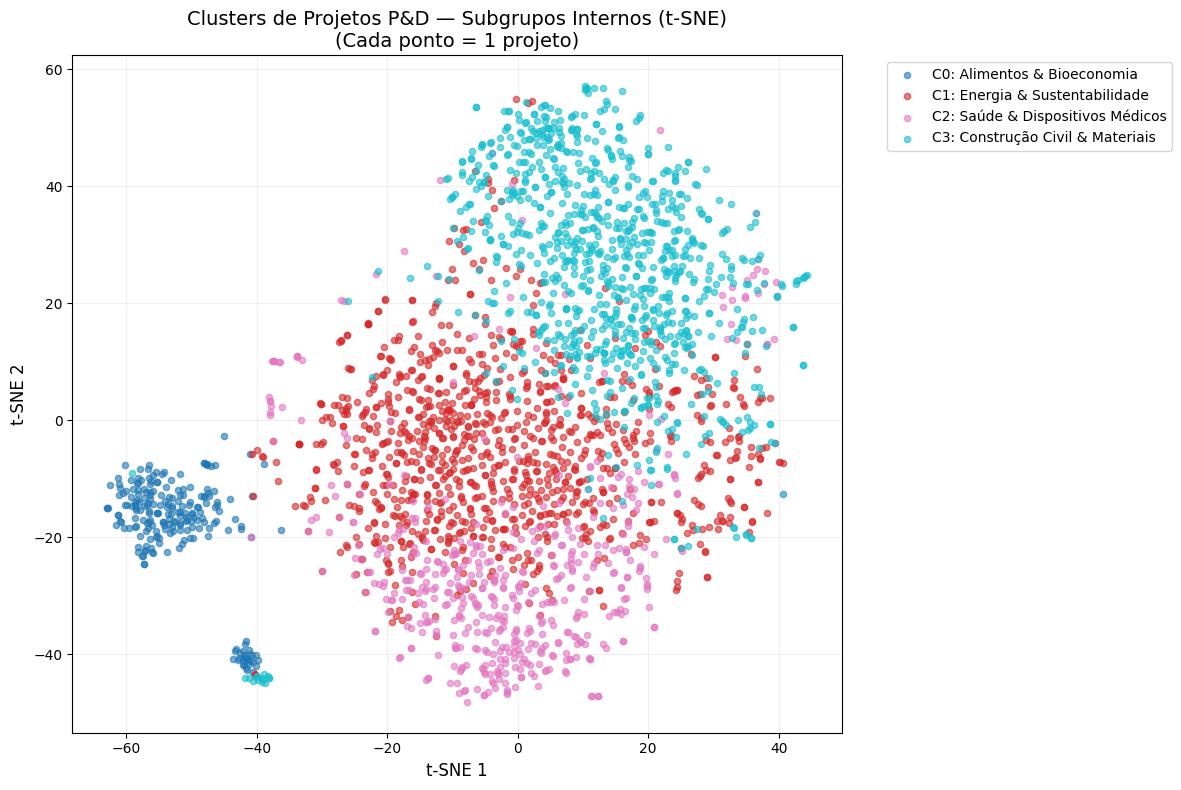

Salvo: clusters_tsne.png


In [12]:
# CÉLULA 12 - VISUALIZAÇÃO T-SNE (subgrupos internos)
# t-SNE revela estrutura LOCAL e subgrupos dentro dos clusters
# ============================================================

n_samples = len(embeddings)
perplexity = min(30, max(5, (n_samples - 1) // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE
)

print(f"Calculando t-SNE (perplexity={perplexity})... pode demorar alguns minutos.")
pontos_tsne = tsne.fit_transform(embeddings)

plot_df_tsne = pd.DataFrame({
    'x': pontos_tsne[:, 0],
    'y': pontos_tsne[:, 1],
    'cluster': df['cluster'].astype(str),
    'nome': df['cluster_nome']
})

plt.figure(figsize=(12, 8))
for i, cid in enumerate(sorted(df['cluster'].unique())):
    subset = plot_df_tsne[plot_df_tsne['cluster'] == str(cid)]
    nome = interpretacoes.get(cid, f'Cluster {cid}')
    plt.scatter(subset['x'], subset['y'],
                label=f"C{cid}: {nome}",
                alpha=0.6, s=20, color=cores[i])

plt.xlabel('t-SNE 1', fontsize=12)
plt.ylabel('t-SNE 2', fontsize=12)
plt.title('Clusters de Projetos P&D — Subgrupos Internos (t-SNE)\n(Cada ponto = 1 projeto)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('clusters_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: clusters_tsne.png")

# ============================================================

## 13. Exportação final (CSV)


In [13]:
# CÉLULA 13 - EXPORTAÇÃO FINAL (CSV COM TUDO)
# ============================================================

# DataFrame principal com resultados
df_export = df[['Título_Público', 'Descricao_pública', 'cluster', 'cluster_nome',
                 'ner_area_aplicacao', 'ner_beneficiario', 'ner_recurso_natural',
                 'ner_ods', 'ner_bioma']].copy()

df_export.columns = ['Título', 'Descrição', 'Cluster_ID', 'Cluster_Nome',
                     'NER_Área_Aplicação', 'NER_Beneficiário', 'NER_Recurso_Natural',
                     'NER_ODS', 'NER_Bioma']

df_export.to_csv('resultado_clusters.csv', index=False, encoding='latin-1')
print("Exportado: resultado_clusters.csv")

# DataFrame resumo dos clusters
cluster_df_final = pd.DataFrame(cluster_summary)
cluster_df_final['interpretacao'] = cluster_df_final['cluster'].map(interpretacoes).fillna('A definir')
cluster_df_final.to_csv('resumo_clusters.csv', index=False, encoding='latin-1')
print("Exportado: resumo_clusters.csv")

# ============================================================

Exportado: resultado_clusters.csv
Exportado: resumo_clusters.csv


## 14. Tabela final para entrega


In [14]:
# CÉLULA 14 - EXIBIR TABELA FINAL PARA ENTREGA
# ============================================================

print("\n" + "="*80)
print("TABELA FINAL — ANÁLISE DE CLUSTERS DE PROJETOS P&D")
print("="*80)

for _, row in cluster_df_final.iterrows():
    print(f"\n{'='*60}")
    print(f"CLUSTER {row['cluster']} | {row['interpretacao']} | {row['quantidade']} projetos")
    print(f"{'='*60}")
    print(f"Termos principais: {row['termos_representativos']}")
    print(f"\nExemplos de projetos:")
    exemplos_lista = row['exemplos_titulos'].split(' | ')
    for ex in exemplos_lista[:5]:
        print(f"  • {ex}")

print(f"\n{'='*80}")
print("Análise concluída!")
print(f"Total de projetos analisados: {len(df)}")
print(f"Número de clusters encontrados: {best_k}")
print("="*80)


TABELA FINAL — ANÁLISE DE CLUSTERS DE PROJETOS P&D

CLUSTER 0 | Alimentos & Bioeconomia | 221 projetos
Termos principais: energia, es, ncia, ao, material, material composito, capacidade, composito, utilizando, eletronica, aguardando autorizacao, natural, aguardando, autorizacao, veiculos

Exemplos de projetos:
  • HUAWEI SOLAR TRACKING CONTROL (AI BASED)
  • ACELERA VTEX
  • DESENVOLVIMENTO DE HARDWARE DE AQUISIÇÃO PARA AUTOMAÇÃO NO REGISTRO E ENVIO DE INFORMAÇÕES DE ARRAÇOAMENTOS
  • PROJETO INTELIGÊNCIA NAS EXECUÇÕES
  • PROTÓTIPO NACIONAL DE BATERIA LÍTIO DE BAIXA TENSÃO PARA ELETRIFICAÇÃO VEICULAR

CLUSTER 1 | Energia & Sustentabilidade | 1037 projetos
Termos principais: energia, ao, ambiente, comunicacao, realizar, maquina, algoritmos, computacional, gerenciamento, veiculos, utilizando, iot, saude, capaz, ia

Exemplos de projetos:
  • AgriGear - Superacabamento de engrenagens para aumento da capacidade de carga de engrenagens agrícolas
  • Caixa de Transmissão IoT para monitorame